Graph saved as fan_speed_output.png


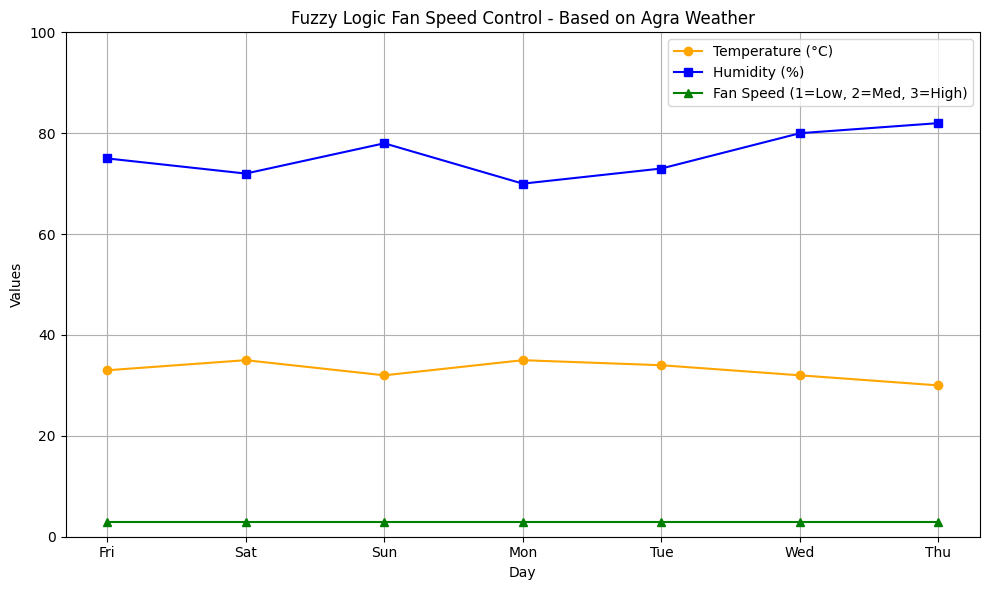

In [1]:
import matplotlib.pyplot as plt

days = ["Fri", "Sat", "Sun", "Mon", "Tue", "Wed", "Thu"]

temperature = [33, 35, 32, 35, 34, 32, 30]   # in °C
humidity = [75, 72, 78, 70, 73, 80, 82]      # in %

fan_speed = []

for t, h in zip(temperature, humidity):

    if t < 30:
        fan_speed.append(1)   # Low

    elif 30 <= t <= 34:

        if h < 60:
            fan_speed.append(2)   # Medium
        else:
            fan_speed.append(3)   # High

    else:
        fan_speed.append(3)   # High


plt.figure(figsize=(10, 6))

plt.plot(days, temperature,
         marker='o',
         label='Temperature (°C)',
         color='orange')

plt.plot(days, humidity,
         marker='s',
         label='Humidity (%)',
         color='blue')

plt.plot(days, fan_speed,
         marker='^',
         label='Fan Speed (1=Low, 2=Med, 3=High)',
         color='green')

plt.title('Fuzzy Logic Fan Speed Control - Based on Agra Weather')

plt.xlabel('Day')
plt.ylabel('Values')

plt.ylim(0, 100)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("fan_speed_output.png")

print("Graph saved as fan_speed_output.png")

Temp: 33°C, Humidity: 75%, Fan Speed: 81.94%
Temp: 35°C, Humidity: 72%, Fan Speed: 79.72%
Temp: 32°C, Humidity: 78%, Fan Speed: 83.22%
Temp: 35°C, Humidity: 70%, Fan Speed: 77.52%
Temp: 34°C, Humidity: 73%, Fan Speed: 80.59%
Temp: 32°C, Humidity: 80%, Fan Speed: 83.71%
Temp: 30°C, Humidity: 82%, Fan Speed: 84.01%


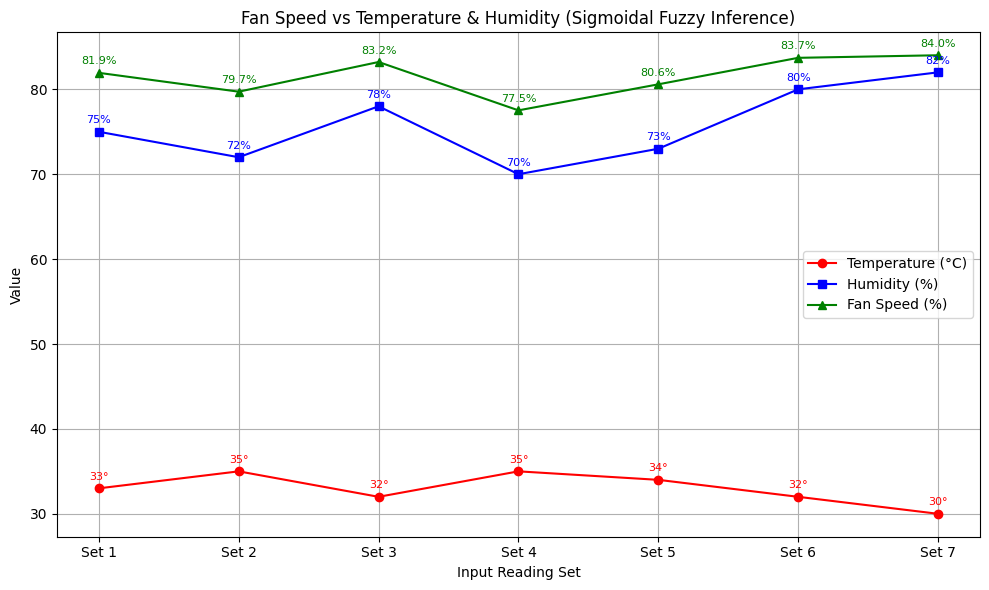

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Define fuzzy variables (universes)
temperature = ctrl.Antecedent(np.arange(0, 51, 1), 'temperature')
humidity = ctrl.Antecedent(np.arange(0, 101, 1), 'humidity')
fan_speed = ctrl.Consequent(np.arange(0, 101, 1), 'fan_speed')

# Define membership functions using sigmoid and Gaussian curves

# Temperature
temperature['low'] = fuzz.sigmf(temperature.universe, 15, -0.3)
temperature['medium'] = fuzz.gaussmf(temperature.universe, 25, 5)
temperature['high'] = fuzz.sigmf(temperature.universe, 30, 0.3)

# Humidity
humidity['low'] = fuzz.sigmf(humidity.universe, 35, -0.3)
humidity['medium'] = fuzz.gaussmf(humidity.universe, 50, 10)
humidity['high'] = fuzz.sigmf(humidity.universe, 65, 0.3)

# Fan Speed
fan_speed['slow'] = fuzz.sigmf(fan_speed.universe, 30, -0.3)
fan_speed['medium'] = fuzz.gaussmf(fan_speed.universe, 50, 10)
fan_speed['fast'] = fuzz.sigmf(fan_speed.universe, 70, 0.3)

# Define fuzzy rules
rules = [
    ctrl.Rule(temperature['low'] & humidity['low'], fan_speed['slow']),
    ctrl.Rule(temperature['medium'] & humidity['medium'], fan_speed['medium']),
    ctrl.Rule(temperature['high'] | humidity['high'], fan_speed['fast']),
    ctrl.Rule(temperature['medium'] & humidity['low'], fan_speed['medium']),
    ctrl.Rule(temperature['high'] & humidity['low'], fan_speed['fast']),
]

# Build and simulate the fuzzy control system
fan_ctrl = ctrl.ControlSystem(rules)
fan_sim = ctrl.ControlSystemSimulation(fan_ctrl)

# Sample realistic inputs (temperature °C, humidity %)
temps = [33, 35, 32, 35, 34, 32, 30]
humids = [75, 72, 78, 70, 73, 80, 82]

fan_speeds = []

# Compute outputs for each input pair
for temp, hum in zip(temps, humids):

    fan_sim.input['temperature'] = temp
    fan_sim.input['humidity'] = hum

    fan_sim.compute()

    speed = fan_sim.output['fan_speed']

    fan_speeds.append(speed)

    print(f"Temp: {temp}°C, Humidity: {hum}%, Fan Speed: {speed:.2f}%")

# Plot the results
x = np.arange(len(temps))
x_labels = [f"Set {i+1}" for i in x]

plt.figure(figsize=(10, 6))

# Plot temperature, humidity, and fan speed
plt.plot(x, temps,
         marker='o',
         color='red',
         label='Temperature (°C)')

plt.plot(x, humids,
         marker='s',
         color='blue',
         label='Humidity (%)')

plt.plot(x, fan_speeds,
         marker='^',
         color='green',
         label='Fan Speed (%)')

# Add value labels
for i in x:

    plt.text(i, temps[i] + 1,
             f"{temps[i]}°",
             ha='center',
             fontsize=8,
             color='red')

    plt.text(i, humids[i] + 1,
             f"{humids[i]}%",
             ha='center',
             fontsize=8,
             color='blue')

    plt.text(i, fan_speeds[i] + 1,
             f"{fan_speeds[i]:.1f}%",
             ha='center',
             fontsize=8,
             color='green')

# Chart styling
plt.xticks(x, x_labels)

plt.title("Fan Speed vs Temperature & Humidity (Sigmoidal Fuzzy Inference)")
plt.xlabel("Input Reading Set")
plt.ylabel("Value")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()